# Matemáticas para aprendizaje automático
## Álgebra lineal
### Entregable 1: PCA y Point Distribution Models

## tl;dr

- Se procesan las **240 imágenes** de **40 personas**, cada una descrita por **58 landmarks** (vectores de dimensión 116).
- El alineamiento Procrustes generalizado converge en **7 iteraciones** y elimina traslación, escala y rotación antes del PCA.
- Los tres primeros modos explican conjuntamente el **70.1 %** de la variabilidad; hacen falta **22 modos** para alcanzar el 95 %.
- Se generan las **9 instancias solicitadas**: los tres primeros modos evaluados en $-3\sqrt{\lambda_i}$, $0$ y $+3\sqrt{\lambda_i}$.

## Contexto y método

El enunciado propone construir un *Point Distribution Model* (PDM) facial mediante cinco pasos:

1. Leer los landmarks anotados en los ficheros `.asf`.
2. Alinear las formas en un sistema de coordenadas común.
3. Construir, para cada cara, $z=[x_1,\ldots,x_n,y_1,\ldots,y_n]^T$ y calcular
   $\widehat{R}=\frac{1}{N}\sum_i(z_i-\widehat{\mu})(z_i-\widehat{\mu})^T$.
4. Descomponer $\widehat{R}=U\Lambda U^T$.
5. Generar formas con $\widetilde{z}=\widehat{\mu}+Ub$.

El lector de anotaciones adapta `transformar_BBDD.py`; el alineamiento adapta `Alinear_landmarks.py`. Se usan los datos ya incluidos en el repositorio, evitando una descarga duplicada y la ruta Unix fija `/tmp/imm_face_db/`.

### Supuestos y decisiones

- Todos los `.asf` comparten el mismo orden y topología de 58 landmarks.
- La covarianza usa el divisor $N$, exactamente como indica el enunciado.
- Se corrige la normalización de la forma media para usar **todos** los landmarks y se calcula la rotación óptima con SVD, equivalente a una formulación estable con `atan2`.
- El signo de cada autovector es arbitrario: las columnas $-3\sqrt{\lambda_i}$ y $+3\sqrt{\lambda_i}$ pueden intercambiarse sin cambiar el modelo.
- El PCA modela variación lineal de forma; no implica que toda forma extrema sea igualmente probable en la población.

## Configuración

Las rutas se resuelven desde la raíz del repositorio o desde la propia carpeta `Notebooks`, de modo que el notebook puede ejecutarse desde ambas ubicaciones.

In [10]:
from pathlib import Path
import sys

import matplotlib as mpl
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from PIL import Image

np.set_printoptions(precision=6, suppress=True)

COLORS = {
    "blue": "#2F5D8A",
    "orange": "#C47722",
    "gold": "#D4A72C",
    "charcoal": "#2D3339",
    "grey": "#7A8288",
}

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#E2E6E9",
    "grid.linewidth": 0.8,
    "font.size": 10,
})


def find_repo_root(start: Path) -> Path:
    '''Busca la raíz que contiene la carpeta del entregable.'''
    start = start.resolve()
    for candidate in (start, *start.parents):
        expected = candidate / "Algebra 1" / "Entregable 1" / "imm_face_db"
        if expected.is_dir():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del repositorio MML.")


REPO_ROOT = find_repo_root(Path.cwd())
DELIVERABLE_DIR = REPO_ROOT / "Algebra 1" / "Entregable 1"
DATA_DIR = DELIVERABLE_DIR / "imm_face_db"
TRANSFORM_SCRIPT = DELIVERABLE_DIR / "Python" / "transformar_BBDD.py"
ALIGN_SCRIPT = DELIVERABLE_DIR / "Python" / "Alinear_landmarks.py"

assert TRANSFORM_SCRIPT.is_file()
assert ALIGN_SCRIPT.is_file()
assert DATA_DIR.is_dir()

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__} | Matplotlib: {mpl.__version__}")
print(f"Datos: {DATA_DIR.relative_to(REPO_ROOT)}")
print(f"Scripts de referencia: {TRANSFORM_SCRIPT.name}, {ALIGN_SCRIPT.name}")

Python: 3.12.9
NumPy: 2.5.3 | Matplotlib: 3.11.2
Datos: Algebra 1\Entregable 1\imm_face_db
Scripts de referencia: transformar_BBDD.py, Alinear_landmarks.py


## Datos
### 1. Lectura de las anotaciones ASF

La función siguiente reproduce la lógica de `getstructure` de `transformar_BBDD.py`: recupera el número de puntos, separa los contornos y determina si cada trayectoria es abierta o cerrada.

In [11]:
def read_asf(asf_path: Path) -> dict:
    '''Lee landmarks, topología e imagen asociada de un fichero ASF.'''
    lines = asf_path.read_text(encoding="utf-8").splitlines()

    number_marker = lines.index("# number of model points")
    n_points = int(lines[number_marker + 2].strip())

    format_index = max(
        index for index, line in enumerate(lines)
        if line.startswith("# format: <path#> <type> <x rel.> <y rel.>")
    )
    data_start = format_index + 2
    rows = [lines[index].split()[:7] for index in range(data_start, data_start + n_points)]

    path_ids = np.array([int(row[0]) for row in rows], dtype=int)
    points = np.array([[float(row[2]), float(row[3])] for row in rows], dtype=float)

    unique_path_ids = np.unique(path_ids)
    path_slices = []
    closed_paths = []
    cursor = 0

    for path_id in unique_path_ids:
        path_rows = [row for row, current_id in zip(rows, path_ids) if current_id == path_id]
        path_length = len(path_rows)
        path_slices.append(slice(cursor, cursor + path_length))
        cursor += path_length

        # Misma regla que usa transformar_BBDD.py para detectar extremos abiertos.
        has_open_endpoint = any(
            row[4] == row[5] or row[4] == row[6]
            for row in path_rows
        )
        closed_paths.append(not has_open_endpoint)

    image_path = asf_path.with_suffix(".jpg")
    return {
        "name": asf_path.stem,
        "points": points,
        "path_slices": tuple(path_slices),
        "closed_paths": tuple(closed_paths),
        "image_path": image_path,
    }


asf_paths = sorted(DATA_DIR.glob("*.asf"))
jpg_paths = sorted(DATA_DIR.glob("*.jpg"))
records = [read_asf(path) for path in asf_paths]
shapes = np.stack([record["points"] for record in records])

reference_slices = records[0]["path_slices"]
reference_closed = records[0]["closed_paths"]
asf_stems = {path.stem for path in asf_paths}
jpg_stems = {path.stem for path in jpg_paths}

def image_size(path: Path) -> tuple[int, int]:
    with Image.open(path) as image:
        return image.size


image_sizes = sorted({image_size(path) for path in jpg_paths})
subjects = {record["name"].split("-")[0] for record in records}
female_images = sum(record["name"].endswith("f") for record in records)
male_images = sum(record["name"].endswith("m") for record in records)

assert len(asf_paths) == len(jpg_paths) == 240
assert asf_stems == jpg_stems
assert shapes.shape == (240, 58, 2)
assert len(subjects) == 40
assert image_sizes == [(640, 480)]
assert np.isfinite(shapes).all()
assert ((0.0 <= shapes) & (shapes <= 1.0)).all()
assert all(record["path_slices"] == reference_slices for record in records)
assert all(record["closed_paths"] == reference_closed for record in records)

summary_rows = [
    ("Muestras", len(records)),
    ("Personas", len(subjects)),
    ("Landmarks por muestra", shapes.shape[1]),
    ("Dimensión de cada vector z", 2 * shapes.shape[1]),
    ("Resolución de las imágenes", f"{image_sizes[0][0]} × {image_sizes[0][1]}"),
    ("Imágenes hombre / mujer", f"{male_images} / {female_images}"),
    ("Contornos por cara", len(reference_slices)),
]

table = "| Comprobación | Resultado |\n|---|---:|\n" + "\n".join(
    f"| {label} | {value} |" for label, value in summary_rows
)
display(Markdown(table))

| Comprobación | Resultado |
|---|---:|
| Muestras | 240 |
| Personas | 40 |
| Landmarks por muestra | 58 |
| Dimensión de cada vector z | 116 |
| Resolución de las imágenes | 640 × 480 |
| Imágenes hombre / mujer | 198 / 42 |
| Contornos por cara | 7 |

### 2. Inspección de una anotación

Se representa una imagen junto con sus siete contornos para comprobar la correspondencia entre coordenadas relativas y píxeles.

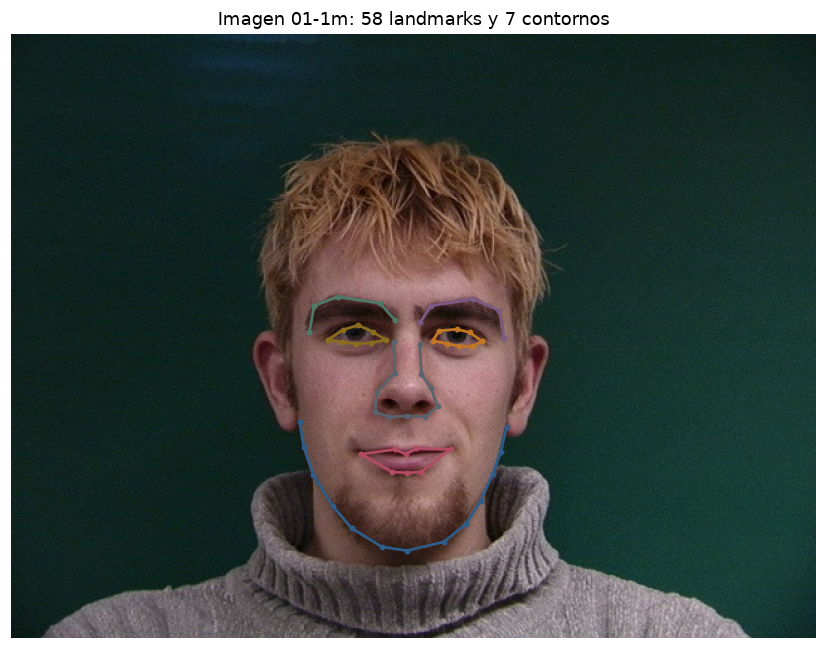

In [12]:
PATH_COLORS = [
    "#2F5D8A", "#C47722", "#8A6D1D", "#7B5A85",
    "#4F7A67", "#B24C63", "#59636E",
]


def close_path(points: np.ndarray, is_closed: bool) -> np.ndarray:
    if is_closed:
        return np.vstack([points, points[0]])
    return points


sample = records[0]
sample_image = mpimg.imread(sample["image_path"])
height, width = sample_image.shape[:2]

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(sample_image)

for path_number, (path_slice, is_closed) in enumerate(
    zip(sample["path_slices"], sample["closed_paths"])
):
    relative_points = close_path(sample["points"][path_slice], is_closed)
    ax.plot(
        relative_points[:, 0] * width,
        relative_points[:, 1] * height,
        color=PATH_COLORS[path_number],
        linewidth=1.8,
        marker="o",
        markersize=2.8,
    )

ax.set_title(f"Imagen {sample['name']}: 58 landmarks y 7 contornos")
ax.set_axis_off()
fig.tight_layout()
plt.show()

## Resultados
### 3. Alineamiento Procrustes generalizado

Primero se centra cada forma. Después se estima, mediante SVD, la rotación propia y la escala que mejor la aproximan a la referencia. La forma media se actualiza hasta convergencia.

In [13]:
def center_shape(shape: np.ndarray) -> np.ndarray:
    return shape - shape.mean(axis=0, keepdims=True)


def normalize_shape(shape: np.ndarray) -> np.ndarray:
    centered = center_shape(shape)
    frobenius_norm = np.linalg.norm(centered)
    if frobenius_norm == 0:
        raise ValueError("No se puede normalizar una forma degenerada.")
    return centered / frobenius_norm


def align_shape_to_reference(shape: np.ndarray, reference: np.ndarray) -> np.ndarray:
    '''Alinea una forma 2D mediante traslación, rotación propia y escala.'''
    centered_shape = center_shape(shape)
    centered_reference = center_shape(reference)

    left_vectors, _, right_vectors_t = np.linalg.svd(
        centered_shape.T @ centered_reference
    )
    rotation = left_vectors @ right_vectors_t

    # Evita reflexiones: el modelo debe conservar la lateralidad de la cara.
    if np.linalg.det(rotation) < 0:
        left_vectors[:, -1] *= -1
        rotation = left_vectors @ right_vectors_t

    rotated = centered_shape @ rotation
    scale = np.sum(rotated * centered_reference) / np.sum(centered_shape**2)
    return scale * rotated


def generalized_procrustes(
    input_shapes: np.ndarray,
    tolerance: float = 1e-12,
    max_iterations: int = 500,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    '''Alinea todas las formas y devuelve formas, referencia e historial.'''
    reference = normalize_shape(input_shapes[0])
    convergence_history = []

    for _ in range(max_iterations):
        aligned = np.stack([
            align_shape_to_reference(shape, reference)
            for shape in input_shapes
        ])
        candidate = normalize_shape(
            align_shape_to_reference(aligned.mean(axis=0), reference)
        )
        change = np.linalg.norm(candidate - reference)
        convergence_history.append(change)
        reference = candidate

        if change < tolerance:
            break
    else:
        raise RuntimeError("El alineamiento no convergió en el máximo de iteraciones.")

    final_aligned = np.stack([
        align_shape_to_reference(shape, reference)
        for shape in input_shapes
    ])
    return final_aligned, reference, np.asarray(convergence_history)


aligned_shapes, reference_shape, convergence_history = generalized_procrustes(shapes)

max_centroid_error = np.abs(aligned_shapes.mean(axis=1)).max()
assert convergence_history[-1] < 1e-12
assert max_centroid_error < 1e-12
assert np.isclose(np.linalg.norm(reference_shape), 1.0)

print(f"Iteraciones: {len(convergence_history)}")
print(f"Cambio final de la referencia: {convergence_history[-1]:.3e}")
print(f"Error máximo de centrado: {max_centroid_error:.3e}")

Iteraciones: 7
Cambio final de la referencia: 2.669e-14
Error máximo de centrado: 3.996e-16


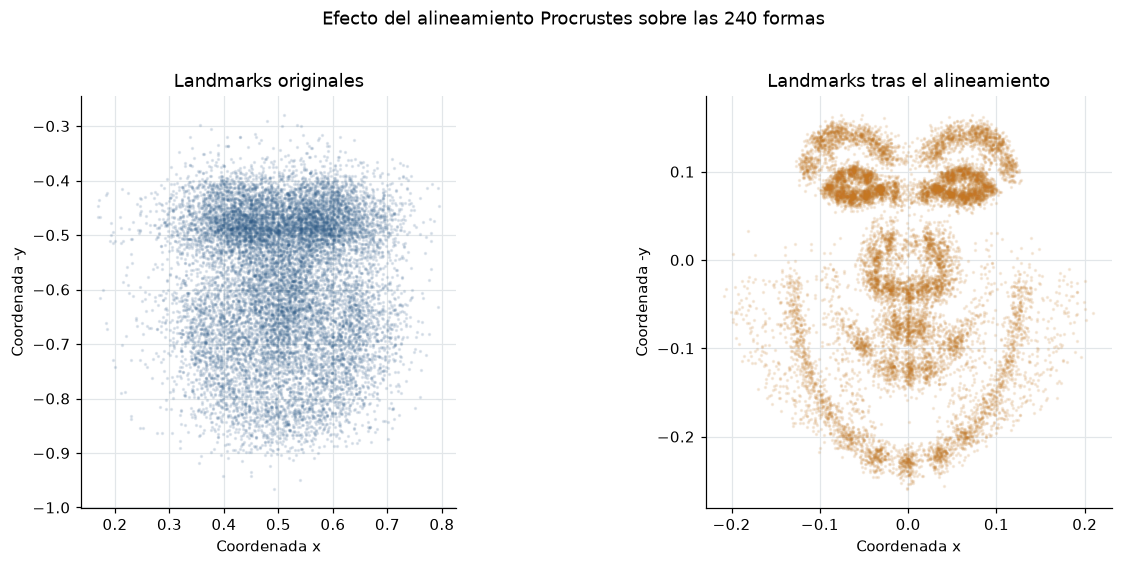

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for shape in shapes:
    axes[0].plot(
        shape[:, 0], -shape[:, 1], ".",
        color=COLORS["blue"], alpha=0.12, markersize=2.5,
    )

for shape in aligned_shapes:
    axes[1].plot(
        shape[:, 0], -shape[:, 1], ".",
        color=COLORS["orange"], alpha=0.12, markersize=2.5,
    )

axes[0].set_title("Landmarks originales")
axes[1].set_title("Landmarks tras el alineamiento")

for ax in axes:
    ax.set_xlabel("Coordenada x")
    ax.set_ylabel("Coordenada -y")
    ax.set_aspect("equal", adjustable="box")

fig.suptitle("Efecto del alineamiento Procrustes sobre las 240 formas", y=1.02)
fig.tight_layout()
plt.show()

### 4. Matriz de datos, covarianza y PCA

La vectorización conserva el orden exigido por el enunciado: primero todas las coordenadas $x$ y después todas las coordenadas $y$. Para una matriz simétrica se usa `numpy.linalg.eigh`, y los autovalores se ordenan de mayor a menor.

In [15]:
n_samples, n_landmarks, _ = aligned_shapes.shape
data_matrix = np.concatenate(
    [aligned_shapes[:, :, 0], aligned_shapes[:, :, 1]],
    axis=1,
)

mean_vector = data_matrix.mean(axis=0)
centered_data = data_matrix - mean_vector
covariance = centered_data.T @ centered_data / n_samples

eigenvalues, eigenvectors = np.linalg.eigh(covariance)
descending_order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[descending_order]
eigenvectors = eigenvectors[:, descending_order]

# Los residuos negativos del orden de 1e-20 son redondeo numérico.
nonnegative_eigenvalues = np.clip(eigenvalues, 0.0, None)
explained_variance = nonnegative_eigenvalues / nonnegative_eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance)
cumulative_eigenvalue_sum = np.cumsum(nonnegative_eigenvalues)

modes_95 = int(np.searchsorted(cumulative_variance, 0.95) + 1)
modes_99 = int(np.searchsorted(cumulative_variance, 0.99) + 1)
top_three_variance = float(cumulative_variance[2])
mode_amplitudes = 3 * np.sqrt(nonnegative_eigenvalues[:3])
numerical_rank = int(np.linalg.matrix_rank(covariance))

orthogonality_error = np.linalg.norm(
    eigenvectors.T @ eigenvectors - np.eye(eigenvectors.shape[1])
)
trace_error = abs(np.trace(covariance) - eigenvalues.sum())

assert data_matrix.shape == (240, 116)
assert covariance.shape == (116, 116)
assert np.all(np.diff(eigenvalues) <= 1e-14)
assert np.allclose(covariance, covariance.T)
assert eigenvalues[-1] > -1e-12
assert orthogonality_error < 1e-10
assert trace_error < 1e-12

print(f"Matriz de datos: {data_matrix.shape}")
print(f"Matriz de covarianza: {covariance.shape}")
print(f"Tres primeros autovalores: {eigenvalues[:3]}")
print(f"Varianza explicada por los 3 primeros modos: {top_three_variance:.2%}")
print(f"Modos necesarios para 95 % / 99 %: {modes_95} / {modes_99}")
print(f"Rango numérico de la covarianza: {numerical_rank}")
print(f"Error de ortogonalidad: {orthogonality_error:.3e}")
print(f"Error traza-suma de autovalores: {trace_error:.3e}")

mode_table = (
    "| Modo | Autovalor | Varianza | Acumulada | $3\\sqrt{\\lambda_i}$ |\n"
    "|---:|---:|---:|---:|---:|\n"
    + "\n".join(
        f"| {index + 1} | {eigenvalues[index]:.9f} | "
        f"{explained_variance[index]:.2%} | {cumulative_variance[index]:.2%} | "
        f"{mode_amplitudes[index]:.6f} |"
        for index in range(3)
    )
)
display(Markdown(mode_table))

Matriz de datos: (240, 116)
Matriz de covarianza: (116, 116)
Tres primeros autovalores: [0.008196 0.002994 0.00114 ]
Varianza explicada por los 3 primeros modos: 70.11%
Modos necesarios para 95 % / 99 %: 22 / 55
Rango numérico de la covarianza: 113
Error de ortogonalidad: 1.826e-14
Error traza-suma de autovalores: 1.041e-17


| Modo | Autovalor | Varianza | Acumulada | $3\sqrt{\lambda_i}$ |
|---:|---:|---:|---:|---:|
| 1 | 0.008196431 | 46.60% | 46.60% | 0.271602 |
| 2 | 0.002993664 | 17.02% | 63.63% | 0.164143 |
| 3 | 0.001139578 | 6.48% | 70.11% | 0.101273 |

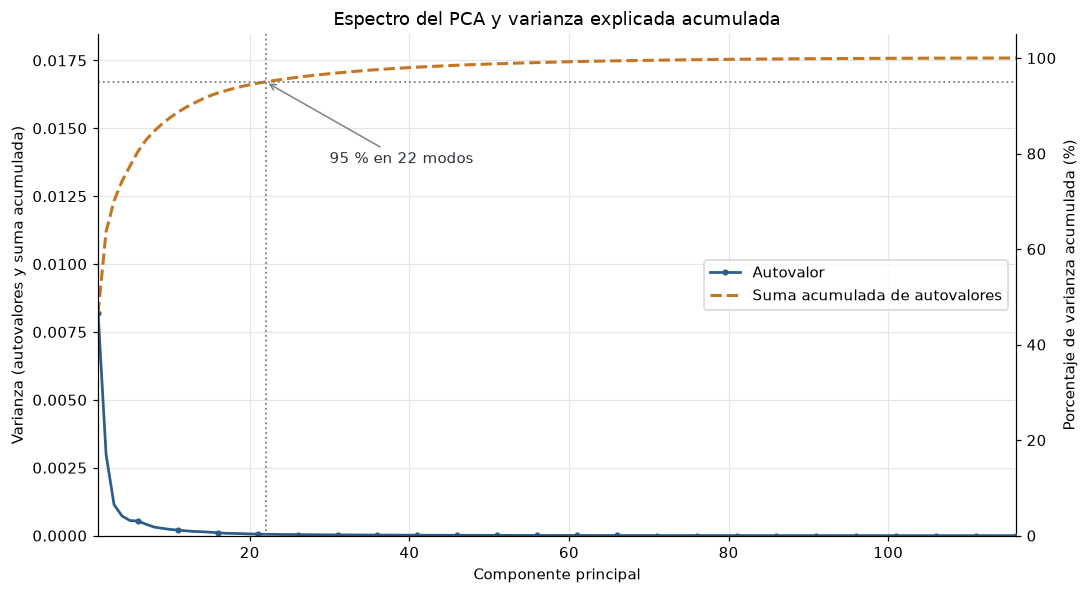

In [16]:
component_numbers = np.arange(1, len(eigenvalues) + 1)
total_variance = nonnegative_eigenvalues.sum()

fig, left_axis = plt.subplots(figsize=(10, 5.5))

eigenvalue_line = left_axis.plot(
    component_numbers,
    nonnegative_eigenvalues,
    color=COLORS["blue"],
    linewidth=1.8,
    marker="o",
    markersize=3,
    markevery=5,
    label="Autovalor",
)
cumulative_line = left_axis.plot(
    component_numbers,
    cumulative_eigenvalue_sum,
    color=COLORS["orange"],
    linewidth=2.0,
    linestyle="--",
    label="Suma acumulada de autovalores",
)

left_axis.axhline(0.95 * total_variance, color=COLORS["grey"], linestyle=":", linewidth=1.2)
left_axis.axvline(modes_95, color=COLORS["grey"], linestyle=":", linewidth=1.2)
left_axis.annotate(
    f"95 % en {modes_95} modos",
    xy=(modes_95, 0.95 * total_variance),
    xytext=(modes_95 + 8, 0.78 * total_variance),
    arrowprops={"arrowstyle": "->", "color": COLORS["grey"]},
    color=COLORS["charcoal"],
)

left_axis.set_title("Espectro del PCA y varianza explicada acumulada")
left_axis.set_xlabel("Componente principal")
left_axis.set_ylabel("Varianza (autovalores y suma acumulada)")
left_axis.set_xlim(1, len(eigenvalues))
left_axis.set_ylim(bottom=0)

percentage_axis = left_axis.secondary_yaxis(
    "right",
    functions=(
        lambda value: 100 * value / total_variance,
        lambda percentage: percentage * total_variance / 100,
    ),
)
percentage_axis.set_ylabel("Porcentaje de varianza acumulada (%)")

lines = eigenvalue_line + cumulative_line
left_axis.legend(lines, [line.get_label() for line in lines], loc="center right")
fig.tight_layout()
plt.show()

### 5. Nueve instancias del Point Distribution Model

Para cada uno de los tres primeros modos se modifica únicamente $b_i$ con los valores $-3\sqrt{\lambda_i}$, $0$ y $+3\sqrt{\lambda_i}$. Todas las subfiguras usan la misma escala para que la comparación geométrica sea honesta.

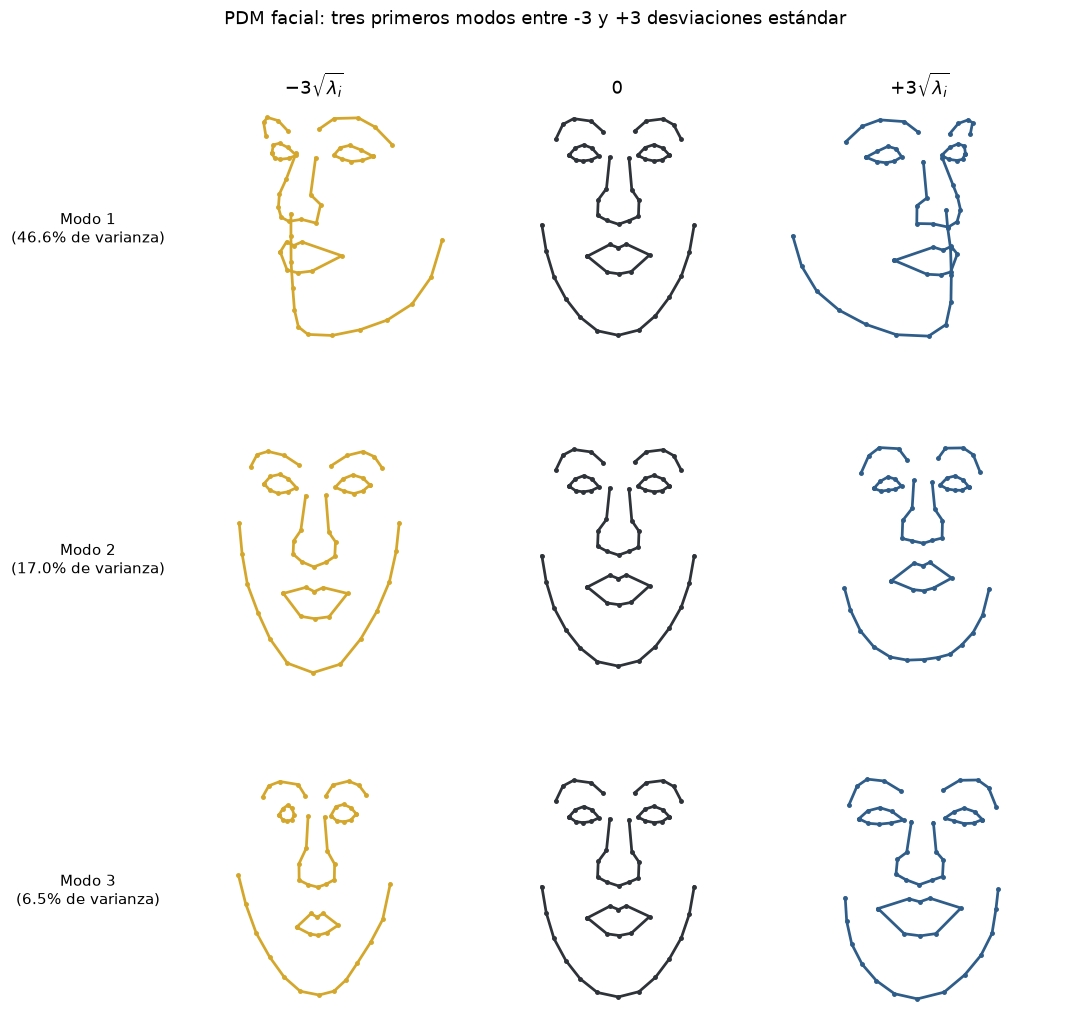

In [17]:
def vector_to_shape(vector: np.ndarray, number_of_landmarks: int) -> np.ndarray:
    '''Invierte z=[x1,...,xn,y1,...,yn] a una matriz n×2.'''
    return np.column_stack([
        vector[:number_of_landmarks],
        vector[number_of_landmarks:],
    ])


def plot_shape_paths(
    ax: plt.Axes,
    shape: np.ndarray,
    color: str,
    linewidth: float = 1.8,
) -> None:
    for path_slice, is_closed in zip(reference_slices, reference_closed):
        path_points = close_path(shape[path_slice], is_closed)
        ax.plot(
            path_points[:, 0],
            -path_points[:, 1],
            color=color,
            linewidth=linewidth,
            marker="o",
            markersize=2.2,
        )


multipliers = np.array([-3.0, 0.0, 3.0])
generated_shapes = np.empty((3, 3, n_landmarks, 2))

for mode_index in range(3):
    standard_deviation = np.sqrt(nonnegative_eigenvalues[mode_index])
    for column_index, multiplier in enumerate(multipliers):
        generated_vector = (
            mean_vector
            + multiplier * standard_deviation * eigenvectors[:, mode_index]
        )
        generated_shapes[mode_index, column_index] = vector_to_shape(
            generated_vector, n_landmarks
        )

display_x = generated_shapes[..., 0]
display_y = -generated_shapes[..., 1]
x_padding = 0.06 * (display_x.max() - display_x.min())
y_padding = 0.06 * (display_y.max() - display_y.min())
x_limits = (display_x.min() - x_padding, display_x.max() + x_padding)
y_limits = (display_y.min() - y_padding, display_y.max() + y_padding)

column_colors = [COLORS["gold"], COLORS["charcoal"], COLORS["blue"]]
column_titles = [r"$-3\sqrt{\lambda_i}$", r"$0$", r"$+3\sqrt{\lambda_i}$"]

fig, axes = plt.subplots(3, 3, figsize=(10, 10), sharex=True, sharey=True)

for mode_index in range(3):
    for column_index in range(3):
        ax = axes[mode_index, column_index]
        plot_shape_paths(
            ax,
            generated_shapes[mode_index, column_index],
            column_colors[column_index],
        )
        ax.set_xlim(*x_limits)
        ax.set_ylim(*y_limits)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(False)

        if mode_index == 0:
            ax.set_title(column_titles[column_index])
        if column_index == 0:
            ax.set_ylabel(
                f"Modo {mode_index + 1}\n"
                f"({explained_variance[mode_index]:.1%} de varianza)",
                rotation=0,
                labelpad=55,
                va="center",
            )

fig.suptitle(
    "PDM facial: tres primeros modos entre -3 y +3 desviaciones estándar",
    y=0.98,
)
fig.subplots_adjust(left=0.17, right=0.98, bottom=0.04, top=0.92, wspace=0.06, hspace=0.08)
plt.show()

### 6. Comprobaciones numéricas

Las comprobaciones siguientes verifican propiedades distintas: simetría de la covarianza, ortogonalidad de los autovectores, conservación de la varianza, reconstrucción completa y coincidencia de las tres formas medias de la columna central.

In [18]:
scores = centered_data @ eigenvectors
reconstructed_data = mean_vector + scores @ eigenvectors.T
relative_reconstruction_error = (
    np.linalg.norm(data_matrix - reconstructed_data)
    / np.linalg.norm(data_matrix)
)

central_shape_error = max(
    np.linalg.norm(generated_shapes[row, 1] - vector_to_shape(mean_vector, n_landmarks))
    for row in range(3)
)

mode_symmetry_error = max(
    np.linalg.norm(
        generated_shapes[row, 0]
        + generated_shapes[row, 2]
        - 2 * vector_to_shape(mean_vector, n_landmarks)
    )
    for row in range(3)
)

variance_identity_error = abs(
    np.trace(covariance)
    - np.mean(np.sum(centered_data**2, axis=1))
)

checks = {
    "Covarianza simétrica": np.allclose(covariance, covariance.T, atol=1e-12),
    "Autovalores en orden descendente": bool(np.all(np.diff(eigenvalues) <= 1e-14)),
    "Autovalores no negativos salvo redondeo": bool(eigenvalues[-1] > -1e-12),
    "Autovectores ortonormales": bool(orthogonality_error < 1e-10),
    "Traza igual a varianza total": bool(trace_error < 1e-12),
    "Traza igual a distancia cuadrática media": bool(variance_identity_error < 1e-12),
    "Reconstrucción con todos los modos": bool(relative_reconstruction_error < 1e-12),
    "Columna central igual a la media": bool(central_shape_error < 1e-12),
    "Extremos simétricos respecto a la media": bool(mode_symmetry_error < 1e-12),
}

assert all(checks.values())

check_table = "| Comprobación | Estado |\n|---|:---:|\n" + "\n".join(
    f"| {name} | {'✓' if passed else '✗'} |"
    for name, passed in checks.items()
)
display(Markdown(check_table))
print(f"Error relativo de reconstrucción: {relative_reconstruction_error:.3e}")
print(f"Error máximo de las formas medias: {central_shape_error:.3e}")
print(f"Error máximo de simetría de los extremos: {mode_symmetry_error:.3e}")

| Comprobación | Estado |
|---|:---:|
| Covarianza simétrica | ✓ |
| Autovalores en orden descendente | ✓ |
| Autovalores no negativos salvo redondeo | ✓ |
| Autovectores ortonormales | ✓ |
| Traza igual a varianza total | ✓ |
| Traza igual a distancia cuadrática media | ✓ |
| Reconstrucción con todos los modos | ✓ |
| Columna central igual a la media | ✓ |
| Extremos simétricos respecto a la media | ✓ |

Error relativo de reconstrucción: 1.903e-16
Error máximo de las formas medias: 0.000e+00
Error máximo de simetría de los extremos: 5.259e-17


## Conclusiones

- La base local es coherente: 240 pares imagen/anotación, 40 sujetos, 58 landmarks y siete contornos por cara.
- El alineamiento converge en siete iteraciones y deja los centroides en cero con error inferior a $10^{-12}$.
- Los autovalores principales son aproximadamente $0.008196$, $0.002994$ y $0.001140$; sus modos acumulan el **70.1 %** de la variación alineada.
- Se necesitan **22 componentes** para explicar al menos el 95 % y 55 para el 99 %.
- La rejilla final contiene exactamente las nueve instancias pedidas. La columna central es, en los tres casos, la forma media; las columnas laterales muestran desplazamientos de tres desviaciones estándar en cada modo.

La resolución queda completamente determinada por los `.asf` locales y puede repetirse ejecutando todas las celdas en orden.